<a href="https://colab.research.google.com/github/Elsacred02/assignment_3_advanced_machine_learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

L'obiettivo è stato quello di modificare la CNN presentata a lezione cercando di massimizzare l'accuratezza del modello, che non deve superare i 7000 parametri addestrabili.

## Dipendenze ed operazioni preliminari

In [14]:
# Import dependencies
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# set seed
keras.utils.set_random_seed(42)

In [15]:
# load the data and divide it into train/test split
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


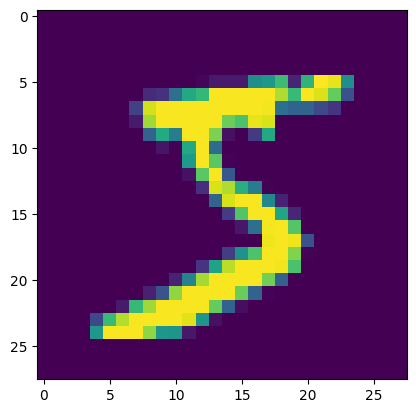

Label: 5


In [16]:
# Show the first element
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
print(f"Label: {y_train[0]}")



In [17]:
# Scale images into the [0 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make images with size (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [18]:
# convert class array into one-hot representation
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# we have seen this class is 5
print(y_train.shape)
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Creazione del modello

Per risolvere l'assignment è stata utilizzata l'idea alla base delle architetture VGG. La rete creata ha:


*   Un **livello di input**, la cui dimensione è pari a quella delle immagini che stiamo prendendo in considerazione.
*   Due **livelli convoluzionali**, ciascuno dei quali è formato da *8* filtri con dimensione *3 x 3*.
*   Un **livello di pooling**, che utilizza la tecnica di scelta del valore massimo all'interno della finestra di dimensione *2 x 2*.
*   Due **livelli convoluzionali**, ciascuno dei quali è formato da *16* filtri di dimesnione *3 x 3*.
*   Un ulteriore **livello di pooling** con la stessa struttura adottata in precedenza.
*   Un **livello di appiattimento**, per ottenere il vettore di feature da fornire in ingresso ad un layer denso per la classificazione.


In questo modo è stato possibile ottenere un modello con meno di 7000 parametri che permettesse di ottenere un'accuratezza elevata nella classificazione (tra il 98.5% circa).

Total params = 6722
= (3 * 3 * 8 + 8) + (3 * 3 * 8 * 8 + 8) + (3 * 3 * 8 * 16 + 16) + (3 * 3 * 16 * 16 + 16) + (256 * 10 + 10) = 80 + 584 + 1168 + 2320 + 2570



In [19]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(8, kernel_size=3, activation="relu"),
      layers.Conv2D(8, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,722 (26.26 KB)

 Trainable params: 6,722 (26.26 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5649 - loss: 1.2380 - val_accuracy: 0.9581 - val_loss: 0.1381
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9284 - loss: 0.2346 - val_accuracy: 0.9759 - val_loss: 0.0846
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9485 - loss: 0.1670 - val_accuracy: 0.9801 - val_loss: 0.0702
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9575 - loss: 0.1397 - val_accuracy: 0.9813 - val_loss: 0.0658
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9628 - loss: 0.1185 - val_accuracy: 0.9826 - val_loss: 0.0586


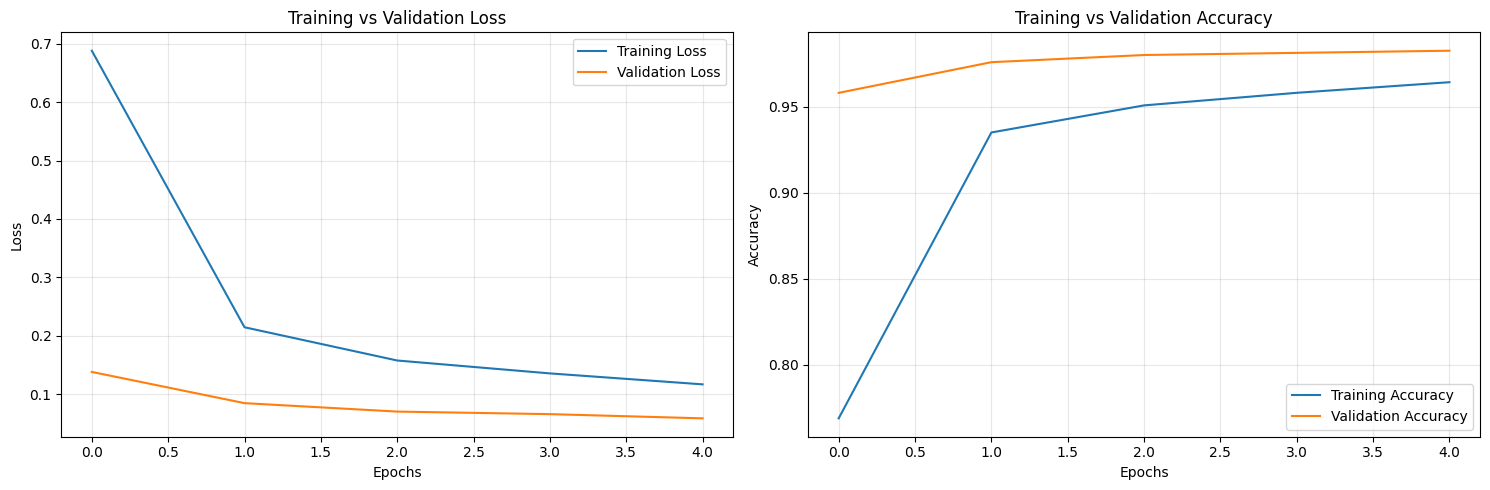

In [21]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.04803251475095749
Test accuracy 0.9847999811172485


# Confronto con modello visto a lezione

In questa sezione viene presentato il modello di CNN visto a lezione; come è possibile notare, a fronte di una diminuzione molto alta del numero di parametri, è stato possibile mantenere l'accuratezza.

In [23]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(32, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(64, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7712 - loss: 0.7856 - val_accuracy: 0.9711 - val_loss: 0.1032
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9608 - loss: 0.1283 - val_accuracy: 0.9793 - val_loss: 0.0745
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.0920 - val_accuracy: 0.9834 - val_loss: 0.0580
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9753 - loss: 0.0782 - val_accuracy: 0.9849 - val_loss: 0.0534
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9791 - loss: 0.0652 - val_accuracy: 0.9865 - val_loss: 0.0477


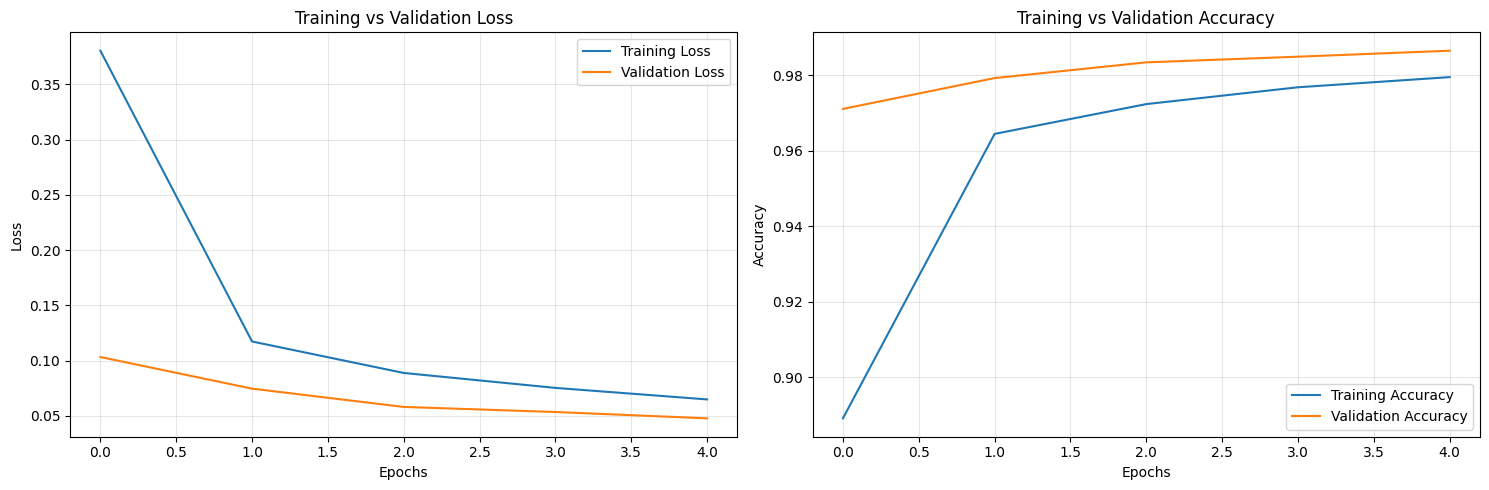

In [25]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.03737897798418999
Test accuracy 0.987500011920929
